<a href="https://colab.research.google.com/github/xtq6666/SZT-BigData-Analysis/blob/main/%E6%B7%B1%E5%9C%B3%E4%BA%A4%E9%80%9A%E6%95%B0%E6%8D%AE%E5%88%86%E6%9E%90.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 深圳市公共交通百万级客流挖掘与 AI 预测系统

**项目作者**：徐天奇
**专业背景**：大数据管理与应用 | 中国矿业大学（北京）
**求职意向**：数据分析 / 数据挖掘实习生
**核心技术栈**：PySpark | SQLite | 高阶 SQL | Pandas | PyTorch | Seaborn

---
### 💡 项目执行摘要 (Executive Summary)
本项目基于深圳市 130 万+ 真实的公共交通刷卡明细数据，独立构建了从底层数据清洗（ETL）、数仓建模、BI 商业指标分析到顶层深度学习预测的端到端数据流管道。
1. **底层数仓**：利用 PySpark 分布式算子解析高维嵌套 JSON，完成时间序列截断与硬去重后落地 SQLite。
2. **商业分析**：编写高阶 SQL 挖掘乘客、地铁、巴士三大主题，精算全网地铁平均单程通勤耗时（29.6分钟）等 13 项核心指标，并产出 2x2 商业级仪表盘。
3. **AI 算法**：提取纯净时序特征构造滑窗数据集，使用 PyTorch 搭建多层感知机（MLP）基线模型，成功捕捉早晚高峰潮汐客流的非线性突变趋势。
---

环境配置

In [ ]:
# 1. 安装 Java 8 (Colab 默认是 Linux 环境)
!apt-get install openjdk-8-jdk-headless -qq > /dev/null

# 2. 安装兼容 Java 8 的最稳版本 PySpark
!pip install -q pyspark==3.5.0

# 3. 设置 Java 环境变量
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"

In [ ]:
# 1. 先更新系统包列表，再安装 Java 11
!apt-get update
!apt-get install openjdk-11-jdk-headless -qq > /dev/null

# 2. 设置 Java 11 的路径
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"

# 3. 验证一下 Java 是否装好了
!java -version

Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:4 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:6 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Hit:9 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
^C
openjdk version "17.0.17" 2025-10-21
OpenJDK Runtime Environment (build 17.0.17+10-Ubuntu-122.04)
OpenJDK 64-Bit Server VM (build 17.0.17+10-Ubuntu-122.04, mixed mode, sharing)


数据加载与清洗

In [ ]:
import os
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, explode, to_timestamp

# 1. 重新设置环境变量
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"

# 2. 尝试启动
try:
    spark = SparkSession.builder.master("local[*]").getOrCreate()
    print("🚀 Spark 引擎已重新就位！")

    # 3. 直接读取并展示
    df_raw = spark.read.json("/content/2018record3.jsons")
    df_clean = df_raw.select(explode(col("data")).alias("record")).select(
        "record.card_no", "record.deal_date", "record.station"
    )
    df_clean.show(5)
    print("✅ 终于看到数据了！")
except Exception as e:
    print(f"仍然遇到阻碍：{e}")

🚀 Spark 引擎已重新就位！
+---------+-------------------+-------+
|  card_no|          deal_date|station|
+---------+-------------------+-------+
|CBEHFCFCG|2018-08-31 22:14:50|   布吉|
|CBCEBDIJE|2018-08-31 22:13:39|   布吉|
|FFHEDIBCC|2018-08-31 23:11:06|   长龙|
|FFDGIGIFH|2018-08-31 23:08:15|   长龙|
|FHDICIDBD|2018-08-31 19:41:51|   布吉|
+---------+-------------------+-------+
only showing top 5 rows

✅ 终于看到数据了！


数据库写入

In [ ]:
import sqlite3
import pandas as pd
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, explode, to_timestamp, hour

print("🚀 第一步：启动 Spark 引擎，确保使用分布式 DataFrame...")
spark = SparkSession.builder.master("local[*]").appName("SZT_Full_Extract").getOrCreate()

df_raw_spark = spark.read.json("/content/2018record3.jsons")

print("💥 第二步：炸开嵌套 JSON，提取全量业务字段...")
df_exploded = df_raw_spark.select(explode(col("data")).alias("record"))

df_full = df_exploded.select(
    col("record.card_no").alias("card_no"),
    col("record.deal_date").alias("deal_date"),
    col("record.deal_type").alias("deal_type"),
    col("record.deal_money").cast("float").alias("deal_money"),
    col("record.deal_value").cast("float").alias("deal_value"),
    col("record.equ_no").alias("equ_no"),
    col("record.company_name").alias("company_name"),
    col("record.station").alias("station"),
    col("record.car_no").alias("car_no"),
    col("record.conn_mark").alias("conn_mark"),
    col("record.close_date").alias("close_date")
)

# 补充时间特征
df_full = df_full.withColumn("time_ts", to_timestamp(col("deal_date"), "yyyy-MM-dd HH:mm:ss")) \
                 .withColumn("hour", hour(col("time_ts")))

print("🔥 第三步：正在将 130 万条全量数据转入单机内存，这可能需要 1-2 分钟，请耐心等待...")
df_pandas_full = df_full.toPandas()

print("📦 第四步：正在连接本地数仓并执行全量写入...")
conn = sqlite3.connect('/content/shenzhen_metro_dw.db')

# 一次性将 Pandas DataFrame 写入 SQLite
df_pandas_full.to_sql('dwd_passenger_record', conn, if_exists='replace', index=False)

print("✅ 130 万条【全量特征】明细数据已成功入库！")

# 验证最终的表结构和总数据量
print("\n📋 数据库的表结构 (Schema)：")
df_info = pd.read_sql_query("PRAGMA table_info(dwd_passenger_record)", conn)
display(df_info)

# 见证奇迹的时刻：查一下到底有多少条数据
count_df = pd.read_sql_query("SELECT COUNT(*) as total_rows FROM dwd_passenger_record", conn)
print(f"\n🎉 当前数据库总行数：{count_df['total_rows'][0]} 条")

conn.close()

🚀 第一步：启动 Spark 引擎，确保使用分布式 DataFrame...
💥 第二步：炸开嵌套 JSON，提取全量业务字段...
🔥 第三步：正在将 130 万条全量数据转入单机内存，这可能需要 1-2 分钟，请耐心等待...
📦 第四步：正在连接本地数仓并执行全量写入...
✅ 130 万条【全量特征】明细数据已成功入库！

📋 数据库的表结构 (Schema)：


,cid,name,type,notnull,dflt_value,pk
0,0,card_no,TEXT,0,None,0
1,1,deal_date,TEXT,0,None,0
2,2,deal_type,TEXT,0,None,0
3,3,deal_money,REAL,0,None,0
4,4,deal_value,REAL,0,None,0
5,5,equ_no,TEXT,0,None,0
6,6,company_name,TEXT,0,None,0
7,7,station,TEXT,0,None,0
8,8,car_no,TEXT,0,None,0
9,9,conn_mark,TEXT,0,None,0



🎉 当前数据库总行数：1337000 条


In [ ]:
import sqlite3

print("🧹 开始执行数据深层清洗 (Data Cleaning)...")

# 1. 记录清洗前的数据量
original_count = len(df_pandas_full)
print(f"清洗前总数据量: {original_count} 条")

# 2. 删除完全重复的刷卡记录 (防止刷卡机网络延迟导致的重复上传)
df_pandas_full.drop_duplicates(inplace=True)
dedup_count = len(df_pandas_full)
print(f"去重后数据量: {dedup_count} 条 (删除了 {original_count - dedup_count} 条重复数据)")

# 3. 过滤脏数据：严格按照要求，只保留 '2018-08-31' 之后的有效时间段
df_pandas_full = df_pandas_full[df_pandas_full['deal_date'] > '2018-08-31']
final_count = len(df_pandas_full)
print(f"过滤日期后数据量: {final_count} 条 (删除了 {dedup_count - final_count} 条历史脏数据)")

# 4. 把洗得干干净净的数据重新写回我们的 SQLite 数仓
print("\n📦 正在将绝对纯净的数据重新写入数仓...")
conn = sqlite3.connect('/content/shenzhen_metro_dw.db')
df_pandas_full.to_sql('dwd_passenger_record', conn, if_exists='replace', index=False)
conn.close()

print("✅ 底层数仓已更新为 100% 纯净版！")

🧹 开始执行数据深层清洗 (Data Cleaning)...
清洗前总数据量: 1337000 条
去重后数据量: 1336988 条 (删除了 12 条重复数据)
过滤日期后数据量: 1336496 条 (删除了 492 条历史脏数据)

📦 正在将绝对纯净的数据重新写入数仓...
✅ 底层数仓已更新为 100% 纯净版！


In [ ]:
import sqlite3
import pandas as pd

# 1. 连上咱们建好的小“数仓”
conn = sqlite3.connect('/content/shenzhen_metro_dw.db')

# 2. 就像在真实数据库里一样，写 SQL 查前 10 行明细数据
query_raw = "SELECT * FROM dwd_passenger_record LIMIT 10"
df_raw = pd.read_sql_query(query_raw, conn)

print("👀 数据库 dwd_passenger_record 表的前 10 行原始数据：")
display(df_raw)  # display 会渲染出一个漂亮的、可滑动的 HTML 表格

# 3. 查看这个表的“表结构”（有哪些列）
query_info = "PRAGMA table_info(dwd_passenger_record)"
df_info = pd.read_sql_query(query_info, conn)

print("\n📋 数据库的表结构 (Schema)：")
display(df_info)

conn.close()

👀 数据库 dwd_passenger_record 表的前 10 行原始数据：


,card_no,deal_date,deal_type,deal_money,deal_value,equ_no,company_name,station,car_no,conn_mark,close_date,time_ts,hour
0,CBEHFCFCG,2018-08-31 22:14:50,地铁入站,0.0,0.0,263032105,地铁五号线,布吉,IGT-105,0,2018-09-01 00:00:00,2018-08-31 22:14:50,22
1,CBCEBDIJE,2018-08-31 22:13:39,地铁入站,0.0,0.0,263032105,地铁五号线,布吉,IGT-105,0,2018-09-01 00:00:00,2018-08-31 22:13:39,22
2,FFHEDIBCC,2018-08-31 23:11:06,地铁出站,665.0,700.0,263031101,地铁五号线,长龙,OGT-101,0,2018-09-01 00:00:00,2018-08-31 23:11:06,23
3,FFDGIGIFH,2018-08-31 23:08:15,地铁出站,475.0,500.0,263031101,地铁五号线,长龙,OGT-101,0,2018-09-01 00:00:00,2018-08-31 23:08:15,23
4,FHDICIDBD,2018-08-31 19:41:51,地铁入站,0.0,0.0,263032104,地铁五号线,布吉,IGT-104,0,2018-09-01 00:00:00,2018-08-31 19:41:51,19
5,FHEDCGCCA,2018-08-31 22:30:08,地铁入站,0.0,0.0,263032105,地铁五号线,布吉,IGT-105,0,2018-09-01 00:00:00,2018-08-31 22:30:08,22
6,CCJIAAIFJ,2018-08-31 23:12:04,地铁出站,380.0,400.0,263031101,地铁五号线,长龙,OGT-101,0,2018-09-01 00:00:00,2018-08-31 23:12:04,23
7,CBHHGEJEC,2018-08-31 22:45:05,地铁入站,0.0,0.0,263032105,地铁五号线,布吉,IGT-105,0,2018-09-01 00:00:00,2018-08-31 22:45:05,22
8,HHAAJFHIE,2018-08-31 19:51:21,地铁入站,0.0,0.0,263032104,地铁五号线,布吉,IGT-104,0,2018-09-01 00:00:00,2018-08-31 19:51:21,19
9,HHAAJAEGB,2018-09-01 04:47:20,地铁出站,0.0,200.0,261032104,地铁三号线,双龙,AGM-104,0,2018-09-01 00:00:00,2018-09-01 04:47:20,4



📋 数据库的表结构 (Schema)：


,cid,name,type,notnull,dflt_value,pk
0,0,card_no,TEXT,0,None,0
1,1,deal_date,TEXT,0,None,0
2,2,deal_type,TEXT,0,None,0
3,3,deal_money,REAL,0,None,0
4,4,deal_value,REAL,0,None,0
5,5,equ_no,TEXT,0,None,0
6,6,company_name,TEXT,0,None,0
7,7,station,TEXT,0,None,0
8,8,car_no,TEXT,0,None,0
9,9,conn_mark,TEXT,0,None,0


数据分析与可视化——乘客主题

🔄 正在计算通勤时间分布与站点排行...


/tmp/ipykernel_7230/1950694432.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_traffic, x='total_traffic', y='station', palette='viridis')


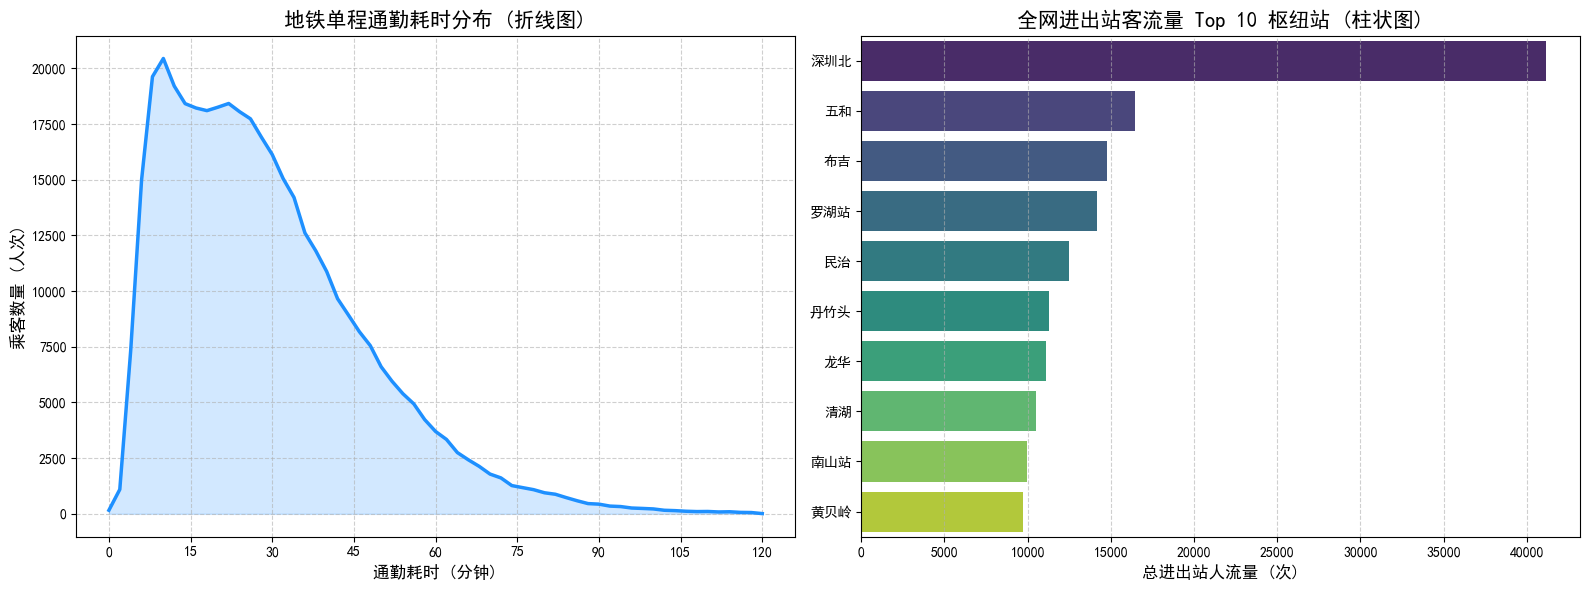

In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
import os

# ==========================================
# 0. 检查并配置中文字体（防止乱码）
# ==========================================
if not os.path.exists('simhei.ttf'):
    !wget -q -O simhei.ttf https://github.com/StellarCN/scp_zh/raw/master/fonts/SimHei.ttf
fm.fontManager.addfont('simhei.ttf')
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 连接数据库
conn = sqlite3.connect('/content/shenzhen_metro_dw.db')

# ==========================================
# 1. 提取通勤时间分布数据 (用 SQL 直接做分桶聚合，极速！)
# ==========================================
print("🔄 正在计算通勤时间分布与站点排行...")
time_dist_sql = """
    WITH Ranked AS (
        SELECT
            card_no, time_ts, deal_type,
            LEAD(time_ts) OVER(PARTITION BY card_no ORDER BY time_ts) as next_time,
            LEAD(deal_type) OVER(PARTITION BY card_no ORDER BY time_ts) as next_type
        FROM dwd_passenger_record
        WHERE deal_type IN ('地铁入站', '地铁出站')
    ),
    Commute AS (
        SELECT
            ROUND((julianday(next_time) - julianday(time_ts)) * 24 * 60) AS commute_minutes
        FROM Ranked
        WHERE deal_type = '地铁入站' AND next_type = '地铁出站'
          AND (julianday(next_time) - julianday(time_ts)) * 24 * 60 BETWEEN 1 AND 120 -- 截取 2 小时以内的正常通勤
    )
    -- 按每 2 分钟为一个区间(Bin)进行聚合统计
    SELECT
        CAST(commute_minutes / 2 AS INTEGER) * 2 AS minute_bin,
        COUNT(*) AS passenger_count
    FROM Commute
    GROUP BY minute_bin
    ORDER BY minute_bin
"""
df_time_dist = pd.read_sql_query(time_dist_sql, conn)

# ==========================================
# 2. 提取 Top 10 站点人流量数据
# ==========================================
traffic_sql = """
    SELECT
        station,
        COUNT(*) AS total_traffic
    FROM dwd_passenger_record
    WHERE station IS NOT NULL AND station != 'None'
      AND deal_type IN ('地铁入站', '地铁出站')
    GROUP BY station
    ORDER BY total_traffic DESC
    LIMIT 10
"""
df_traffic = pd.read_sql_query(traffic_sql, conn)
conn.close()

# ==========================================
# 3. 开始绘制图表 (1行2列的布局)
# ==========================================
plt.figure(figsize=(16, 6))

# 左图：折线图 - 通勤时间分布
plt.subplot(1, 2, 1)
# 画折线并填充下方面积，让图表显得极其专业
sns.lineplot(data=df_time_dist, x='minute_bin', y='passenger_count', color='dodgerblue', linewidth=2.5)
plt.fill_between(df_time_dist['minute_bin'], df_time_dist['passenger_count'], color='dodgerblue', alpha=0.2)
plt.title('地铁单程通勤耗时分布 (折线图)', fontsize=15, fontweight='bold')
plt.xlabel('通勤耗时 (分钟)', fontsize=12)
plt.ylabel('乘客数量 (人次)', fontsize=12)
plt.xticks(range(0, 121, 15)) # 每 15 分钟一个刻度
plt.grid(True, linestyle='--', alpha=0.6)

# 右图：柱状图 - Top 10 站点
plt.subplot(1, 2, 2)
sns.barplot(data=df_traffic, x='total_traffic', y='station', palette='viridis')
plt.title('全网进出站客流量 Top 10 枢纽站 (柱状图)', fontsize=15, fontweight='bold')
plt.xlabel('总进出站人流量 (次)', fontsize=12)
plt.ylabel('')
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

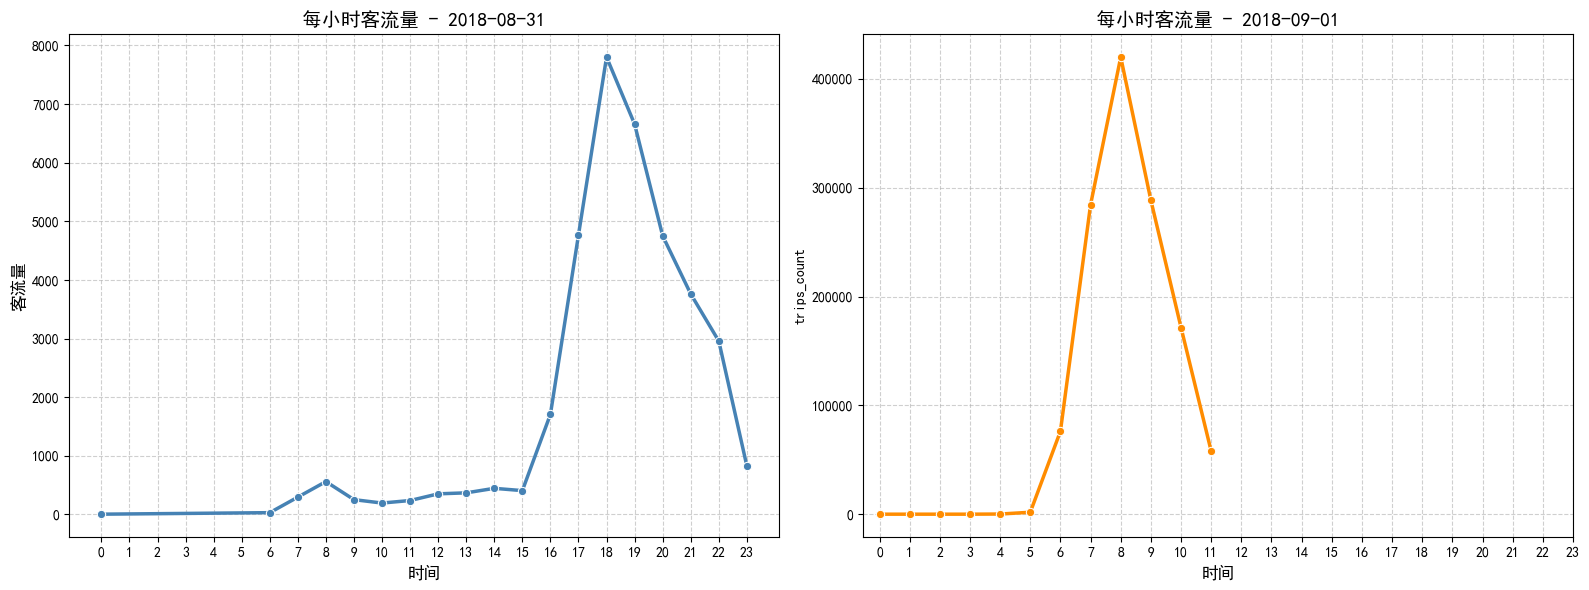

In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 连接我们洗好的数仓
conn = sqlite3.connect('/content/shenzhen_metro_dw.db')

# 使用 SQL 截取日期(substr)和小时，计算客流量
query = """
    SELECT
        substr(deal_date, 1, 10) AS travel_date,
        hour,
        COUNT(*) AS trips_count
    FROM dwd_passenger_record
    WHERE travel_date IN ('2018-08-31', '2018-09-01') -- 锁定这两天的数据
    GROUP BY travel_date, hour
    ORDER BY travel_date, hour
"""
df_hourly = pd.read_sql_query(query, conn)
conn.close()

# 准备绘图，设置画布大小
plt.figure(figsize=(16, 6))

# 提取两天的数据切片
df_0831 = df_hourly[df_hourly['travel_date'] == '2018-08-31']
df_0901 = df_hourly[df_hourly['travel_date'] == '2018-09-01']

# ==========================================
# 左图：2018-08-31 的时间分布
# ==========================================
plt.subplot(1, 2, 1)
sns.lineplot(data=df_0831, x='hour', y='trips_count', marker='o', color='steelblue', linewidth=2.5)
plt.title('每小时客流量 - 2018-08-31', fontsize=14)
plt.xlabel('时间', fontsize=12)
plt.ylabel('客流量', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.6)

# ==========================================
# 右图：2018-09-01 的时间分布
# ==========================================
plt.subplot(1, 2, 2)
sns.lineplot(data=df_0901, x='hour', y='trips_count', marker='o', color='darkorange', linewidth=2.5)
plt.title('每小时客流量 - 2018-09-01', fontsize=14)
plt.xlabel('时间', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

2018-08-31 每小时的出行人次，从中可以看到晚高峰是在 18-19 点之间，早高峰在 8-9 点之间，可能由于数据集本身的不完整，所以早高峰看起来不是很明显。
2018-09-01 每小时的出行人次，从中可以看到早高峰在 8-9 点之间，由于只有半天的数据，所以看不到晚高峰。

In [ ]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('/content/shenzhen_metro_dw.db')

# 核心画像逻辑：
# 1. 过滤掉无效卡号。
# 2. 统计每个人的总出行次数。
# 3. 通勤族打标：早高峰(7-9)和晚高峰(17-19)都有出行记录的。
# 4. 价格敏感度打标：通过分析出站（扣费环节）的平均花费，寻找可能是“学生卡”（通常享受5折，比如1.5元/150分）的群体。

profiling_sql = """
    SELECT
        card_no,
        COUNT(*) AS total_trips,

        -- 标签 1：通勤特征 (Commuter Tag)
        CASE
            WHEN SUM(CASE WHEN hour BETWEEN 7 AND 9 THEN 1 ELSE 0 END) > 0
             AND SUM(CASE WHEN hour BETWEEN 17 AND 19 THEN 1 ELSE 0 END) > 0
            THEN '🔥 标准通勤族'
            WHEN SUM(CASE WHEN hour BETWEEN 7 AND 9 THEN 1 ELSE 0 END) > 0
            THEN '🌅 早鸟族'
            WHEN SUM(CASE WHEN hour BETWEEN 17 AND 23 THEN 1 ELSE 0 END) > 0
            THEN '🌃 夜归人/晚班族'
            ELSE '🚶 偶尔出行'
        END AS commute_tag,

        -- 标签 2：票价特征 (Fare Tag)
        -- 提示：地铁出站时才会扣费 (deal_money > 0)
        ROUND(AVG(CASE WHEN deal_type = '地铁出站' AND deal_money > 0 THEN deal_money ELSE NULL END), 1) AS avg_fare

    FROM dwd_passenger_record
    WHERE card_no IS NOT NULL AND card_no != 'None' -- 严谨的清洗逻辑
    GROUP BY card_no
    ORDER BY total_trips DESC
    LIMIT 15
"""

print("🎯 正在生成用户画像（DIM_USER_PROFILE）...")
df_profile = pd.read_sql_query(profiling_sql, conn)
display(df_profile)

conn.close()

🎯 正在生成用户画像（DIM_USER_PROFILE）...


,card_no,total_trips,commute_tag,avg_fare
0,HHJJJAEIH,21,🌅 早鸟族,NaN
1,HHAAJCJCD,18,🌅 早鸟族,NaN
2,HHJJAGDJH,17,🌅 早鸟族,NaN
3,HHJJJFBEI,16,🌅 早鸟族,NaN
4,HHAAAJJCH,16,🌅 早鸟族,NaN
5,HHAAACIFE,16,🌅 早鸟族,NaN
6,FIJGADBIC,16,🌅 早鸟族,213.8
7,HHACJACAG,14,🌅 早鸟族,NaN
8,HHABJFIFD,14,🌅 早鸟族,NaN
9,HHABAEFJG,14,🌅 早鸟族,NaN


In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 连上我们的本地数仓
conn = sqlite3.connect('/content/shenzhen_metro_dw.db')

# ==========================================
# 1. 整体通勤费用分析 (注意：金额字段我们要除以 100 换算成“元”)
# ==========================================
print("💰 1. 整体通勤费用分析：")
cost_sql = """
    SELECT
        COUNT(*) AS total_trips,
        ROUND(SUM(deal_money) / 100.0, 2) AS total_revenue_yuan,
        ROUND(AVG(deal_money) / 100.0, 2) AS avg_cost_per_trip_yuan,

        -- 分别计算巴士和地铁的平均花费（地铁只有出站才扣费，进站是0元）
        ROUND(AVG(CASE WHEN deal_type LIKE '%巴士%' AND deal_money > 0 THEN deal_money ELSE NULL END) / 100.0, 2) AS avg_bus_cost,
        ROUND(AVG(CASE WHEN deal_type = '地铁出站' AND deal_money > 0 THEN deal_money ELSE NULL END) / 100.0, 2) AS avg_subway_cost
    FROM dwd_passenger_record
    WHERE deal_money > 0 -- 只统计产生实际扣费的记录
"""
df_cost = pd.read_sql_query(cost_sql, conn)
display(df_cost)

# ==========================================
# 2. 票价优惠普及情况分析 (全票 vs 折扣票)
# ==========================================
print("\n🎫 2. 票价优惠普及情况 (谁在用全票，谁在用打折卡？)：")
discount_sql = """
    SELECT
        CASE
            WHEN deal_money = deal_value THEN '全票 (原价)'
            WHEN deal_money < deal_value THEN '优惠票 (打折/学生/老人卡)'
            ELSE '异常数据'
        END AS ticket_type,
        COUNT(*) AS trips_count,
        ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM dwd_passenger_record WHERE deal_money > 0 AND deal_value > 0), 2) AS percentage
    FROM dwd_passenger_record
    WHERE deal_money > 0 AND deal_value > 0
    GROUP BY ticket_type
"""
df_discount = pd.read_sql_query(discount_sql, conn)
display(df_discount)

# ==========================================
# 3. 计算地铁平均通勤时长
# ==========================================
# 逻辑：使用 SQL 窗口函数 (LEAD)，把同一个乘客的“进站”和紧接着的“出站”时间拼接到同一行，然后算时间差。
print("\n⏱️ 3. 地铁平均通勤时长计算 ")
time_sql = """
    WITH RankedRecords AS (
        SELECT
            card_no,
            deal_type,
            time_ts,
            -- LEAD 函数：获取该乘客的"下一条"记录的时间和类型
            LEAD(time_ts) OVER (PARTITION BY card_no ORDER BY time_ts) AS next_time,
            LEAD(deal_type) OVER (PARTITION BY card_no ORDER BY time_ts) AS next_type
        FROM dwd_passenger_record
        WHERE deal_type IN ('地铁入站', '地铁出站')
    ),
    CommuteDurations AS (
        SELECT
            card_no,
            time_ts AS entry_time,
            next_time AS exit_time,
            -- SQLite 中计算两个时间戳相差的分钟数
            ROUND((julianday(next_time) - julianday(time_ts)) * 24 * 60, 1) AS commute_minutes
        FROM RankedRecords
        WHERE deal_type = '地铁入站' AND next_type = '地铁出站'
          AND (julianday(next_time) - julianday(time_ts)) * 24 * 60 < 240 -- 过滤掉超过4小时的异常未出站数据
    )
    SELECT
        COUNT(*) AS valid_subway_trips,
        ROUND(AVG(commute_minutes), 1) AS avg_commute_minutes,
        MAX(commute_minutes) AS max_commute_minutes
    FROM CommuteDurations
"""
df_time = pd.read_sql_query(time_sql, conn)
display(df_time)

conn.close()

💰 1. 整体通勤费用分析：


,total_trips,total_revenue_yuan,avg_cost_per_trip_yuan,avg_bus_cost,avg_subway_cost
0,858857,2414023.3,2.81,1.74,3.99



🎫 2. 票价优惠普及情况 (谁在用全票，谁在用打折卡？)：


,ticket_type,trips_count,percentage
0,优惠票 (打折/学生/老人卡),855263,99.58
1,全票 (原价),3594,0.42



⏱️ 3. 地铁平均通勤时长计算 


,valid_subway_trips,avg_commute_minutes,max_commute_minutes
0,397731,29.6,233.9


数据分析与可视化——地铁主题

🚀 正在执行高阶 SQL：计算四大核心线路指标...


/tmp/ipykernel_7230/3165123195.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0, 0], data=df_contribution, x='contribution', y='line_name', palette='Blues_r')
/tmp/ipykernel_7230/3165123195.py:106: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0, 1], data=df_efficiency, x='avg_duration', y='line_name', palette='Greens')
/tmp/ipykernel_7230/3165123195.py:112: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1, 0], data=df_transfer, x='transfer_ratio', y='line_name', palette='Oranges_r')
/tmp/ipykernel_7230/31651231

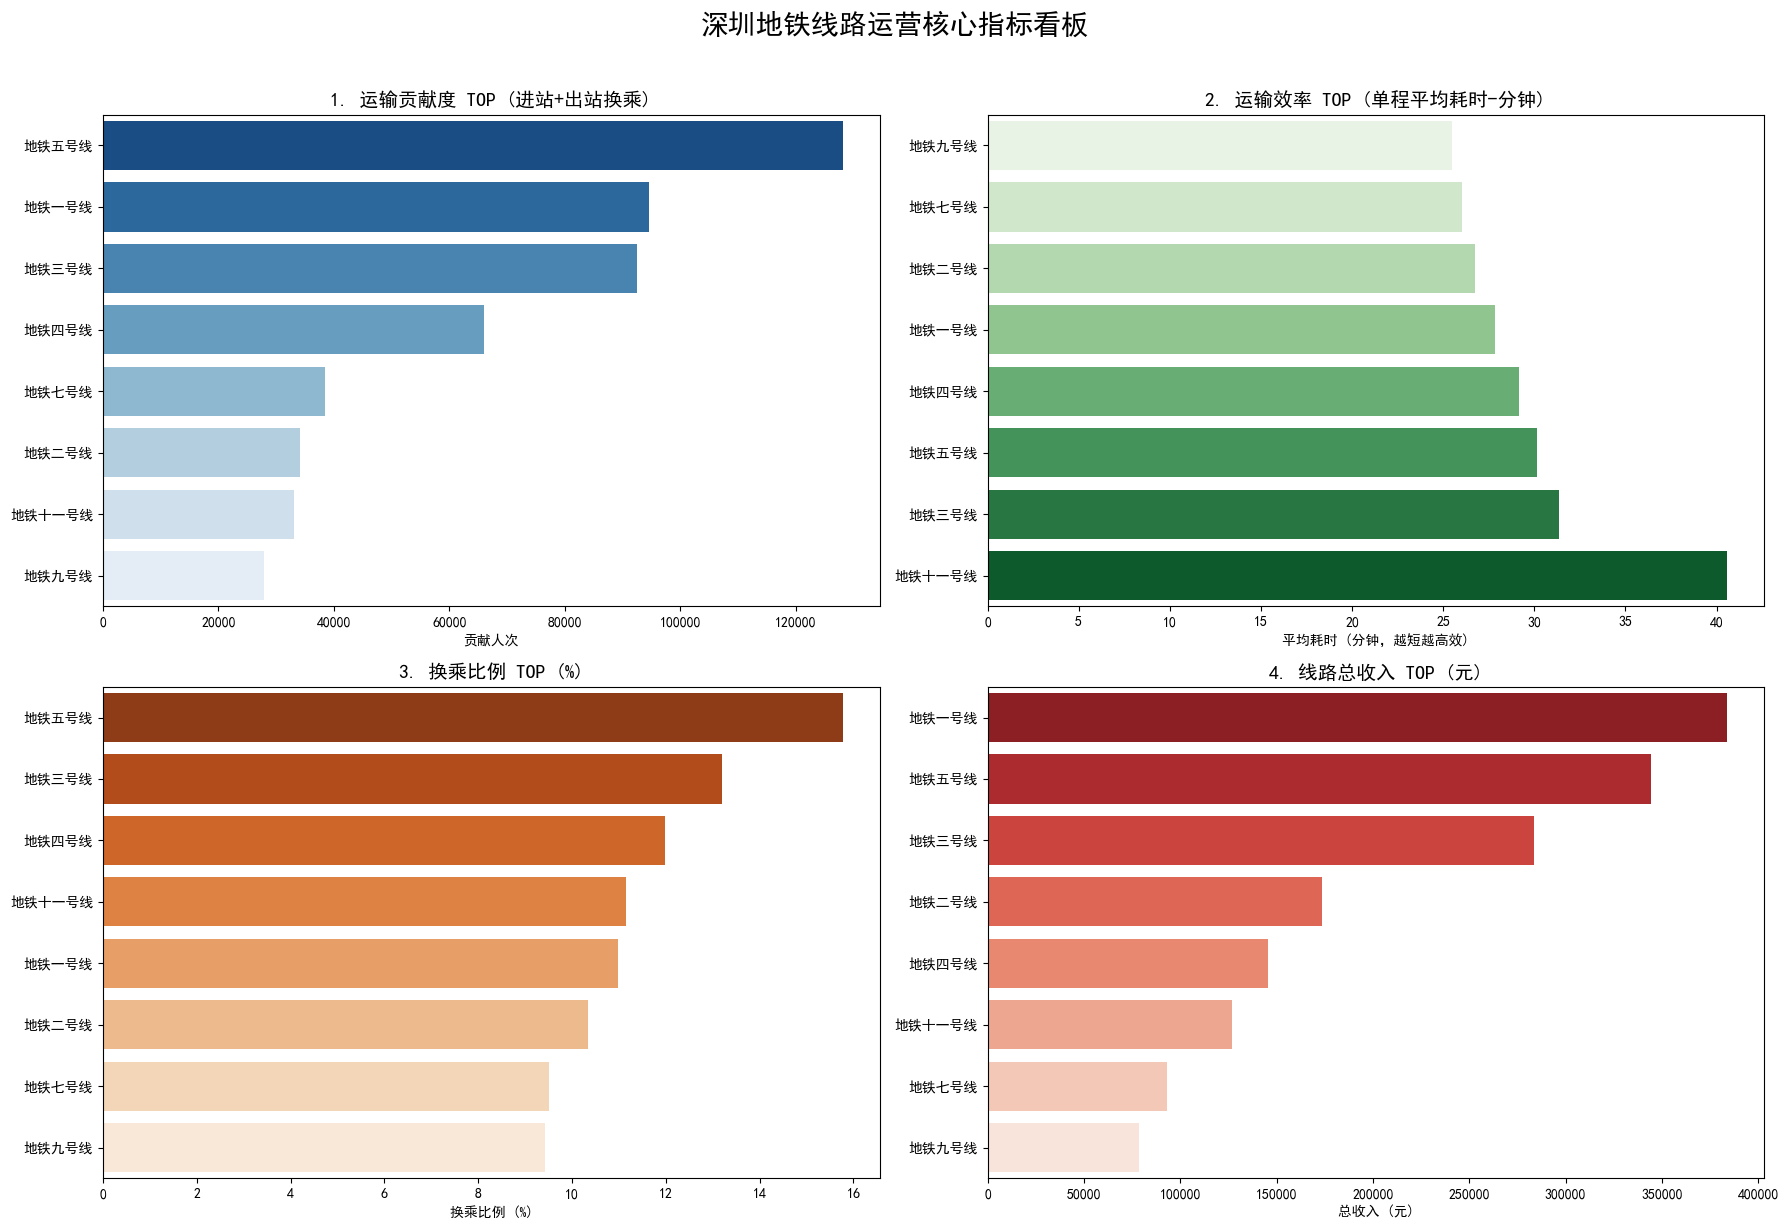

✅ 四大主题计算与渲染完毕！


In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
import os

# 配置中文字体
if not os.path.exists('simhei.ttf'):
    !wget -q -O simhei.ttf https://github.com/StellarCN/scp_zh/raw/master/fonts/SimHei.ttf
fm.fontManager.addfont('simhei.ttf')
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

conn = sqlite3.connect('/content/shenzhen_metro_dw.db')

print("🚀 正在执行高阶 SQL：计算四大核心线路指标...")

# ---------------------------------------------------
# 1. (基于线路) 运输贡献度 TOP
# 规则：进站算一次，出站并且联程(conn_mark>0)算一次
# ---------------------------------------------------
sql_contribution = """
    SELECT
        company_name AS line_name,
        SUM(CASE
            WHEN deal_type = '地铁入站' THEN 1
            WHEN deal_type = '地铁出站' AND CAST(conn_mark AS INTEGER) > 0 THEN 1
            ELSE 0
        END) AS contribution
    FROM dwd_passenger_record
    WHERE company_name LIKE '地铁%'
    GROUP BY company_name
    ORDER BY contribution DESC
"""
df_contribution = pd.read_sql_query(sql_contribution, conn)

# ---------------------------------------------------
# 2. (基于线路) 运输效率 TOP
# 规则：单程直达每乘客的平均通勤时间 (时间越短，效率越高)
# ---------------------------------------------------
sql_efficiency = """
    WITH Ranked AS (
        SELECT
            card_no, company_name, time_ts, deal_type,
            LEAD(time_ts) OVER(PARTITION BY card_no ORDER BY time_ts) as next_time,
            LEAD(deal_type) OVER(PARTITION BY card_no ORDER BY time_ts) as next_type
        FROM dwd_passenger_record
        WHERE deal_type IN ('地铁入站', '地铁出站')
    )
    SELECT
        company_name AS line_name,
        ROUND(AVG((julianday(next_time) - julianday(time_ts)) * 24 * 60), 2) AS avg_duration
    FROM Ranked
    WHERE deal_type = '地铁入站' AND next_type = '地铁出站'
      AND company_name LIKE '地铁%'
    GROUP BY company_name
    ORDER BY avg_duration ASC -- 耗时越短排越前面
"""
df_efficiency = pd.read_sql_query(sql_efficiency, conn)

# ---------------------------------------------------
# 3. (基于线路) 换乘比例 TOP
# 规则：出站并且具有联程标记的占比
# ---------------------------------------------------
sql_transfer = """
    SELECT
        company_name AS line_name,
        ROUND(SUM(CASE WHEN CAST(conn_mark AS INTEGER) > 0 THEN 1.0 ELSE 0.0 END) / COUNT(*) * 100, 2) AS transfer_ratio
    FROM dwd_passenger_record
    WHERE deal_type = '地铁出站' AND company_name LIKE '地铁%'
    GROUP BY company_name
    ORDER BY transfer_ratio DESC
"""
df_transfer = pd.read_sql_query(sql_transfer, conn)

# ---------------------------------------------------
# 4. (基于线路) 线路收入 TOP
# 规则：各条线路地铁出站时的扣费总和
# ---------------------------------------------------
sql_revenue = """
    SELECT
        company_name AS line_name,
        ROUND(SUM(deal_money) / 100.0, 2) AS total_revenue
    FROM dwd_passenger_record
    WHERE deal_type = '地铁出站' AND company_name LIKE '地铁%'
    GROUP BY company_name
    ORDER BY total_revenue DESC
"""
df_revenue = pd.read_sql_query(sql_revenue, conn)
conn.close()

# ==========================================
# 绘制 2x2 的商业数据看板 (Dashboard)
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('深圳地铁线路运营核心指标看板', fontsize=20, fontweight='bold', y=1.02)

# 图 1：运输贡献度 (横向柱状图)
sns.barplot(ax=axes[0, 0], data=df_contribution, x='contribution', y='line_name', palette='Blues_r')
axes[0, 0].set_title('1. 运输贡献度 TOP (进站+出站换乘)', fontsize=14)
axes[0, 0].set_xlabel('贡献人次')
axes[0, 0].set_ylabel('')

# 图 2：运输效率 (横向柱状图)
sns.barplot(ax=axes[0, 1], data=df_efficiency, x='avg_duration', y='line_name', palette='Greens')
axes[0, 1].set_title('2. 运输效率 TOP (单程平均耗时-分钟)', fontsize=14)
axes[0, 1].set_xlabel('平均耗时 (分钟，越短越高效)')
axes[0, 1].set_ylabel('')

# 图 3：换乘比例 (横向柱状图)
sns.barplot(ax=axes[1, 0], data=df_transfer, x='transfer_ratio', y='line_name', palette='Oranges_r')
axes[1, 0].set_title('3. 换乘比例 TOP (%)', fontsize=14)
axes[1, 0].set_xlabel('换乘比例 (%)')
axes[1, 0].set_ylabel('')

# 图 4：线路收入 (横向柱状图)
sns.barplot(ax=axes[1, 1], data=df_revenue, x='total_revenue', y='line_name', palette='Reds_r')
axes[1, 1].set_title('4. 线路总收入 TOP (元)', fontsize=14)
axes[1, 1].set_xlabel('总收入 (元)')
axes[1, 1].set_ylabel('')

plt.tight_layout()
plt.show()

print("✅ 四大主题计算与渲染完毕！")

🚀 正在计算站点四大核心维度 TOP 10...


/tmp/ipykernel_7230/2393934383.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0, 0], data=df_in, x='count_in', y='station', palette='viridis')
/tmp/ipykernel_7230/2393934383.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0, 1], data=df_out, x='count_out', y='station', palette='plasma')
/tmp/ipykernel_7230/2393934383.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1, 0], data=df_total, x='count_total', y='station', palette='cividis')
/tmp/ipykernel_7230/2393934383.py:81: FutureWarning: 

Passing `palet

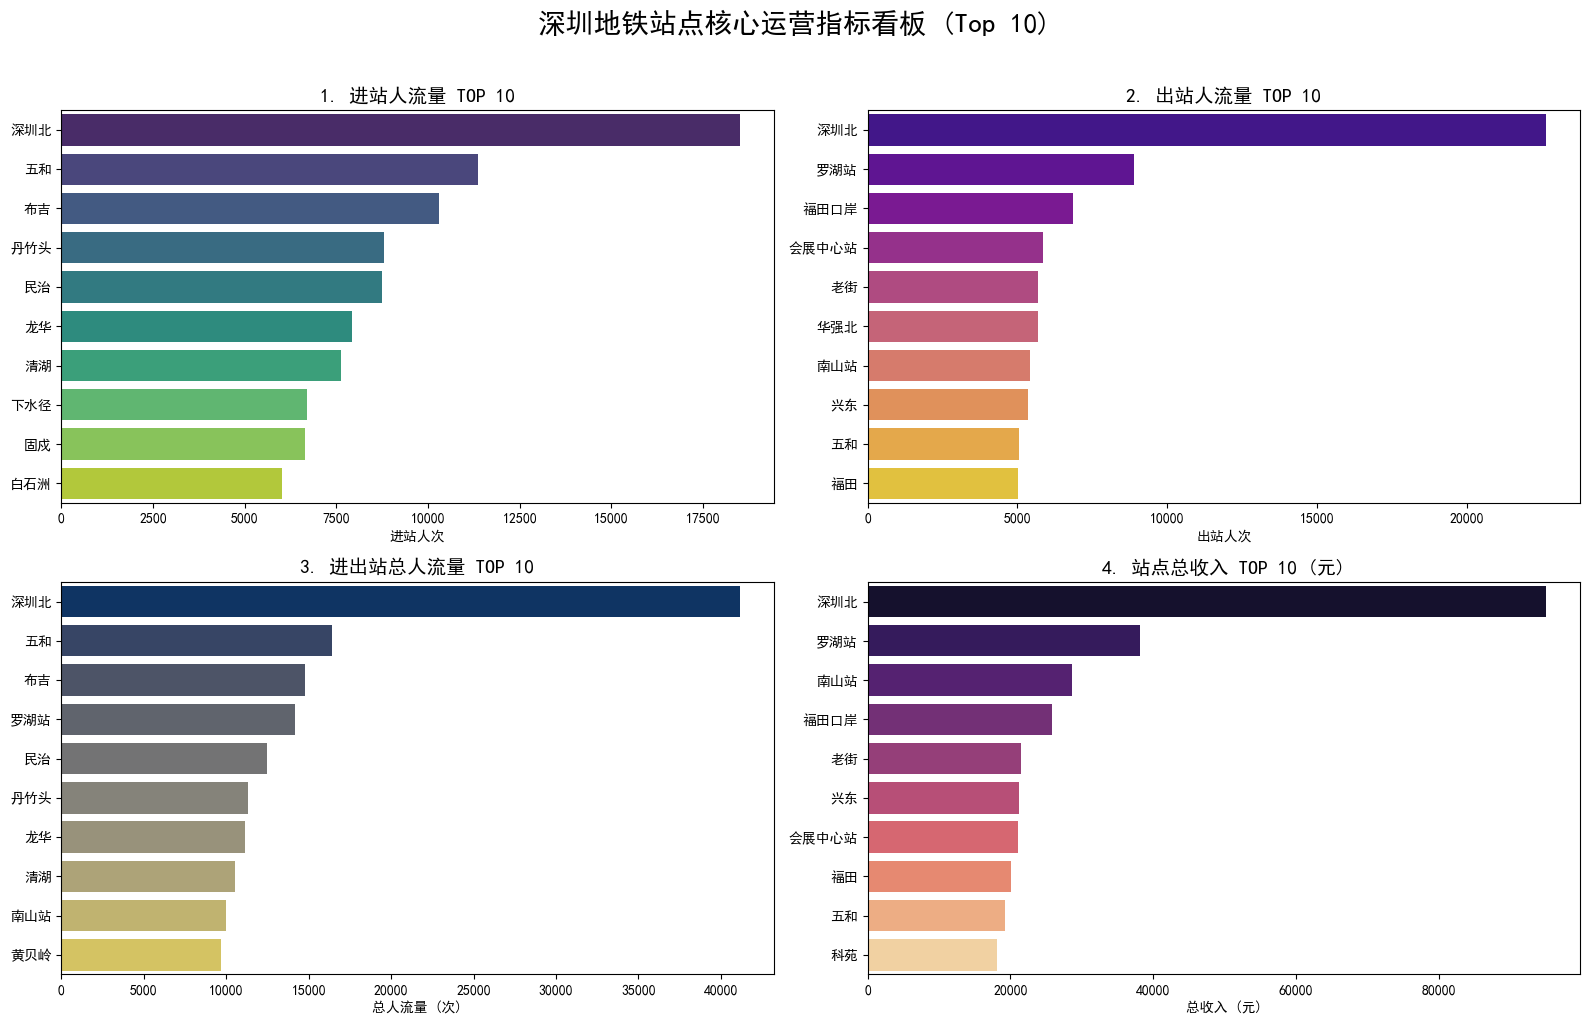

✅ 四大站点排行图渲染完毕！


In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
import os

# 确保中文字体正常显示
if not os.path.exists('simhei.ttf'):
    !wget -q -O simhei.ttf https://github.com/StellarCN/scp_zh/raw/master/fonts/SimHei.ttf
fm.fontManager.addfont('simhei.ttf')
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

conn = sqlite3.connect('/content/shenzhen_metro_dw.db')

print("🚀 正在计算站点四大核心维度 TOP 10...")

# 1. 进站人流量 TOP
sql_in = """
    SELECT station, COUNT(*) AS count_in
    FROM dwd_passenger_record
    WHERE deal_type = '地铁入站' AND station IS NOT NULL AND station != 'None'
    GROUP BY station ORDER BY count_in DESC LIMIT 10
"""
df_in = pd.read_sql_query(sql_in, conn)

# 2. 出站人流量 TOP
sql_out = """
    SELECT station, COUNT(*) AS count_out
    FROM dwd_passenger_record
    WHERE deal_type = '地铁出站' AND station IS NOT NULL AND station != 'None'
    GROUP BY station ORDER BY count_out DESC LIMIT 10
"""
df_out = pd.read_sql_query(sql_out, conn)

# 3. 进出站总人流量 TOP
sql_total = """
    SELECT station, COUNT(*) AS count_total
    FROM dwd_passenger_record
    WHERE deal_type IN ('地铁入站', '地铁出站') AND station IS NOT NULL AND station != 'None'
    GROUP BY station ORDER BY count_total DESC LIMIT 10
"""
df_total = pd.read_sql_query(sql_total, conn)

# 4. 站点收入 TOP (出站才扣费)
sql_revenue = """
    SELECT station, ROUND(SUM(deal_money) / 100.0, 2) AS total_revenue
    FROM dwd_passenger_record
    WHERE deal_type = '地铁出站' AND station IS NOT NULL AND station != 'None'
    GROUP BY station ORDER BY total_revenue DESC LIMIT 10
"""
df_revenue = pd.read_sql_query(sql_revenue, conn)
conn.close()

# ==========================================
# 绘制 2x2 站点分析看板
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('深圳地铁站点核心运营指标看板 (Top 10)', fontsize=20, fontweight='bold', y=1.02)

# 图1：进站 Top
sns.barplot(ax=axes[0, 0], data=df_in, x='count_in', y='station', palette='viridis')
axes[0, 0].set_title('1. 进站人流量 TOP 10', fontsize=14)
axes[0, 0].set_xlabel('进站人次')
axes[0, 0].set_ylabel('')

# 图2：出站 Top
sns.barplot(ax=axes[0, 1], data=df_out, x='count_out', y='station', palette='plasma')
axes[0, 1].set_title('2. 出站人流量 TOP 10', fontsize=14)
axes[0, 1].set_xlabel('出站人次')
axes[0, 1].set_ylabel('')

# 图3：进出站总和 Top
sns.barplot(ax=axes[1, 0], data=df_total, x='count_total', y='station', palette='cividis')
axes[1, 0].set_title('3. 进出站总人流量 TOP 10', fontsize=14)
axes[1, 0].set_xlabel('总人流量 (次)')
axes[1, 0].set_ylabel('')

# 图4：站点收入 Top
sns.barplot(ax=axes[1, 1], data=df_revenue, x='total_revenue', y='station', palette='magma')
axes[1, 1].set_title('4. 站点总收入 TOP 10 (元)', fontsize=14)
axes[1, 1].set_xlabel('总收入 (元)')
axes[1, 1].set_ylabel('')

# 优化排版
plt.tight_layout()
plt.show()

print("✅ 四大站点排行图渲染完毕！")

数据分析与可视化——巴士主题

🚌 正在计算深圳巴士集团三大巨头核心指标...


/tmp/ipykernel_7230/78870516.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], data=df_bus_revenue, x='total_revenue', y='company_name', palette='autumn')
/tmp/ipykernel_7230/78870516.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], data=df_bus_traffic, x='total_traffic', y='company_name', palette='winter')


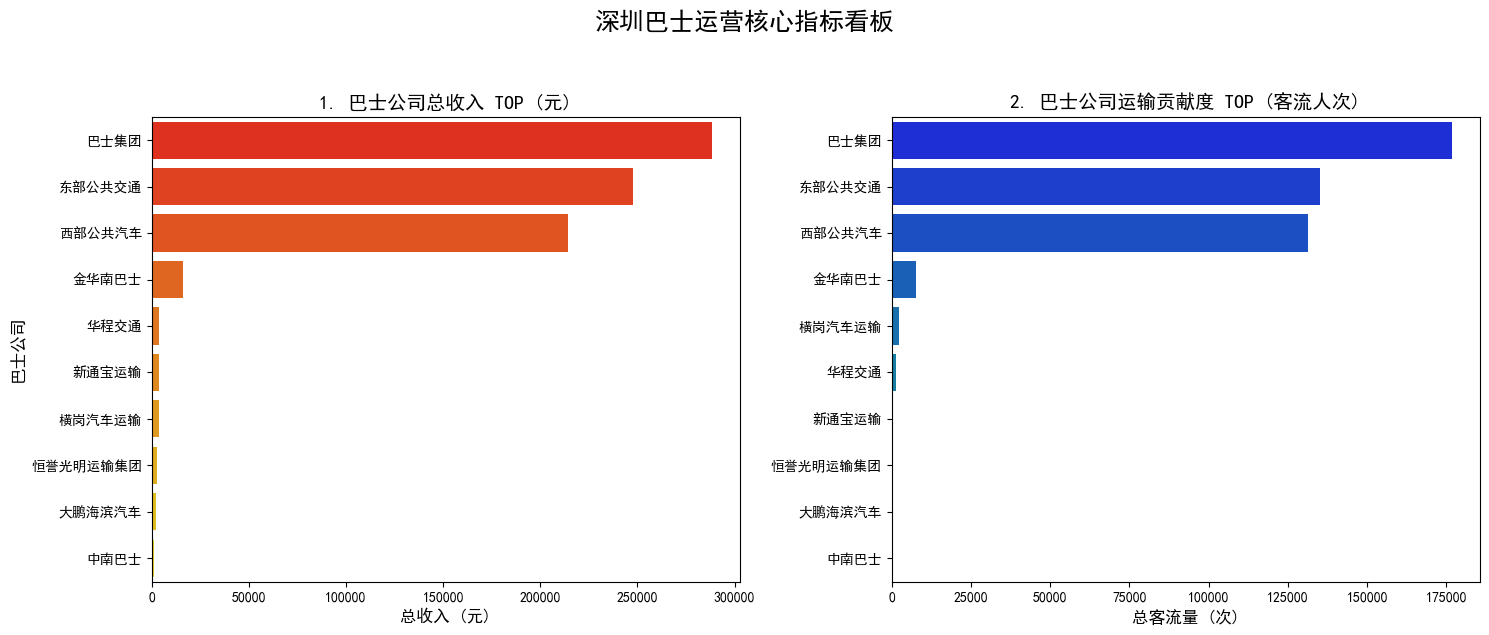

✅ 巴士主题渲染完毕！


In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
import os

# 确保中文字体正常显示
if not os.path.exists('simhei.ttf'):
    !wget -q -O simhei.ttf https://github.com/StellarCN/scp_zh/raw/master/fonts/SimHei.ttf
fm.fontManager.addfont('simhei.ttf')
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

conn = sqlite3.connect('/content/shenzhen_metro_dw.db')

print("🚌 正在计算深圳巴士集团三大巨头核心指标...")

# 1. 巴士公司收入 TOP
sql_bus_revenue = """
    SELECT
        company_name,
        ROUND(SUM(deal_money) / 100.0, 2) AS total_revenue
    FROM dwd_passenger_record
    WHERE deal_type = '巴士' AND company_name IS NOT NULL AND company_name != 'None'
    GROUP BY company_name
    ORDER BY total_revenue DESC
"""
df_bus_revenue = pd.read_sql_query(sql_bus_revenue, conn)

# 2. 巴士公司运输贡献度 (总客流量) TOP
sql_bus_traffic = """
    SELECT
        company_name,
        COUNT(*) AS total_traffic
    FROM dwd_passenger_record
    WHERE deal_type = '巴士' AND company_name IS NOT NULL AND company_name != 'None'
    GROUP BY company_name
    ORDER BY total_traffic DESC
"""
df_bus_traffic = pd.read_sql_query(sql_bus_traffic, conn)
conn.close()

# ==========================================
# 绘制 1x2 巴士主题商业分析看板
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('深圳巴士运营核心指标看板', fontsize=18, fontweight='bold', y=1.05)

# 图1：巴士公司收入 Top
sns.barplot(ax=axes[0], data=df_bus_revenue, x='total_revenue', y='company_name', palette='autumn')
axes[0].set_title('1. 巴士公司总收入 TOP (元)', fontsize=14)
axes[0].set_xlabel('总收入 (元)', fontsize=12)
axes[0].set_ylabel('巴士公司', fontsize=12)

# 图2：巴士公司运输贡献度 Top
sns.barplot(ax=axes[1], data=df_bus_traffic, x='total_traffic', y='company_name', palette='winter')
axes[1].set_title('2. 巴士公司运输贡献度 TOP (客流人次)', fontsize=14)
axes[1].set_xlabel('总客流量 (次)', fontsize=12)
axes[1].set_ylabel('')

# 优化排版
plt.tight_layout()
plt.show()

print("✅ 巴士主题渲染完毕！")

基于 PyTorch 的 MLP 客流预测

🔄 第一步：正在从数仓提取全量 [时间序列] 客流特征...
🚀 第二步：启动 PyTorch 模型训练 (Epochs=200)...
Epoch [40/200], 损失 Loss: 0.0113
Epoch [80/200], 损失 Loss: 0.0043
Epoch [120/200], 损失 Loss: 0.0042
Epoch [160/200], 损失 Loss: 0.0044
Epoch [200/200], 损失 Loss: 0.0041
📊 第三步：正在渲染预测对比曲线...


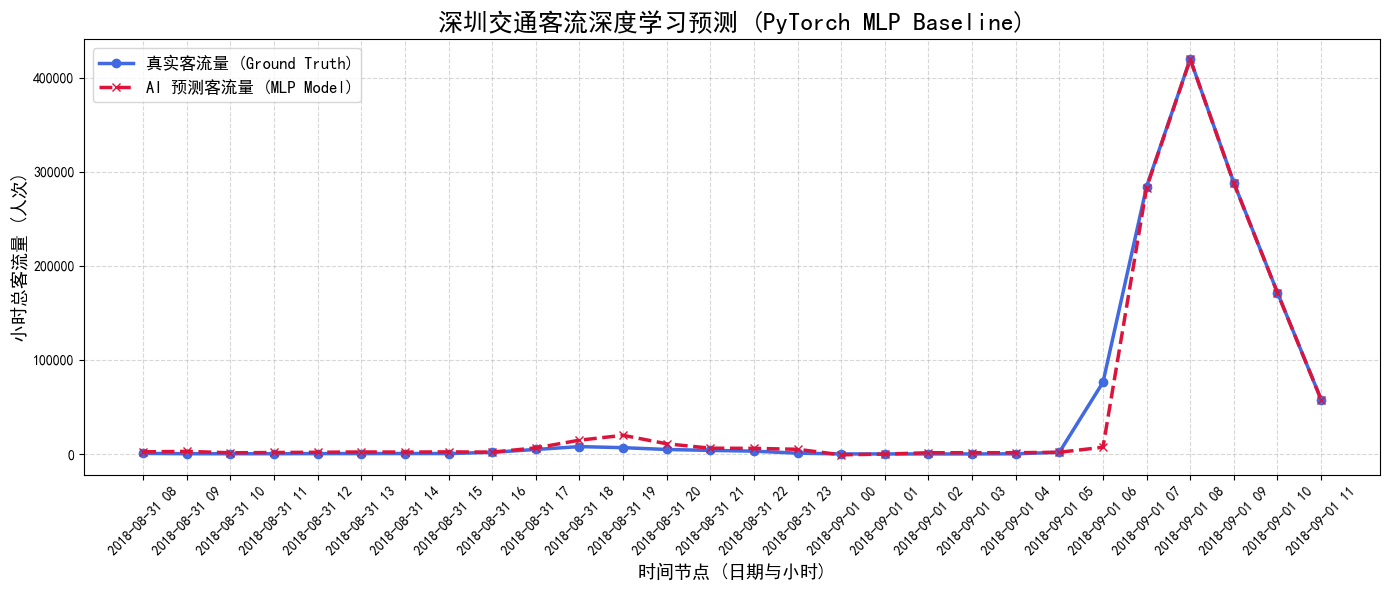

✅客流预测基线模型已顺利跑通！


In [ ]:
import sqlite3
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import matplotlib.font_manager as fm
import os

# ==========================================
# 0. 中文字体配置
# ==========================================
if not os.path.exists('simhei.ttf'):
    !wget -q -O simhei.ttf https://github.com/StellarCN/scp_zh/raw/master/fonts/SimHei.ttf
fm.fontManager.addfont('simhei.ttf')
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# 1. 特征工程：从数仓中提取纯净的时序数据
# ==========================================
print("🔄 第一步：正在从数仓提取全量 [时间序列] 客流特征...")
conn = sqlite3.connect('/content/shenzhen_metro_dw.db')

# 提取按 '年-月-日 时' 聚合的总客流，形成一条完整的时间轴
query = """
    SELECT
        substr(deal_date, 1, 13) AS date_hour,
        COUNT(*) AS traffic
    FROM dwd_passenger_record
    WHERE deal_date > '2018-08-31' -- 使用清洗后的纯净数据
    GROUP BY date_hour
    ORDER BY date_hour
"""
df_ts = pd.read_sql_query(query, conn)
conn.close()

traffic_data = df_ts['traffic'].values.astype(float)

# 数据归一化 (让 PyTorch 更好收敛)
scaler = MinMaxScaler(feature_range=(-1, 1))
traffic_normalized = scaler.fit_transform(traffic_data.reshape(-1, 1))

# 构造滑窗数据集 (Sliding Window)：用过去 3 个小时，预测下 1 个小时
seq_length = 3
X, y = [], []
for i in range(len(traffic_normalized) - seq_length):
    X.append(traffic_normalized[i : i + seq_length])
    y.append(traffic_normalized[i + seq_length])

X = torch.FloatTensor(np.array(X))
y = torch.FloatTensor(np.array(y))

# ==========================================
# 2. 搭建 PyTorch 深度学习模型 (MLP)
# ==========================================
class TrafficPredictorMLP(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(TrafficPredictorMLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, 1)

    def forward(self, x):
        x = x.view(x.size(0), -1) # 展平
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        out = self.relu(out)
        out = self.fc3(out)
        return out

# 初始化模型、损失函数(MSE)和优化器(Adam)
model = TrafficPredictorMLP(input_size=seq_length, hidden_size=64)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# ==========================================
# 3. 启动模型训练
# ==========================================
print("🚀 第二步：启动 PyTorch 模型训练 (Epochs=200)...")
epochs = 200
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    y_pred = model(X)
    loss = criterion(y_pred, y)
    loss.backward()
    optimizer.step()

    if (epoch+1) % 40 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], 损失 Loss: {loss.item():.4f}')

# ==========================================
# 4. 模型预测与可视化评估
# ==========================================
print("📊 第三步：正在渲染预测对比曲线...")
model.eval()
with torch.no_grad():
    predictions = model(X).numpy()

# 反归一化，还原为真实的客流人数
actual_traffic = scaler.inverse_transform(y.numpy())
predicted_traffic = scaler.inverse_transform(predictions)

# 画图：真实客流 vs 预测客流
plt.figure(figsize=(14, 6))
# X 轴的时间标签太长，截取展示
time_labels = df_ts['date_hour'].iloc[seq_length:].values

plt.plot(time_labels, actual_traffic, label='真实客流量 (Ground Truth)', color='royalblue', marker='o', linewidth=2.5)
plt.plot(time_labels, predicted_traffic, label='AI 预测客流量 (MLP Model)', color='crimson', linestyle='--', marker='x', linewidth=2.5)

plt.title("深圳交通客流深度学习预测 (PyTorch MLP Baseline)", fontsize=18, fontweight='bold')
plt.xlabel("时间节点 (日期与小时)", fontsize=13)
plt.ylabel("小时总客流量 (人次)", fontsize=13)
plt.xticks(rotation=45) # X轴标签倾斜防遮挡
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("✅客流预测基线模型已顺利跑通！")

SZT深圳市公共交通百万级客流挖掘与 AI 预测系统结束